In [1]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_kl_gamma-0.2_vq_beta-0.3_target_data-heart_description-None/42/best_20251119_141941.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


Model(
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (k_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (v_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (attn_proj_list): ModuleList(
        (0): Linear(in_features=2304, out_features=1, bias=True)
      )
      (edge_update): Sequential(
        (0): Linear(in_features=1536, out_features=768, bias=True)
        (1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Linear(in_features=768, out_features=768, bias=True)
      )
    )
  )
  (basis_layer_norms): ModuleList(
    (0-1): 2 x LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (sheads): ModuleList(
    (0-3): 4 x Sequential(
      (0): LayerN

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=1, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [26]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





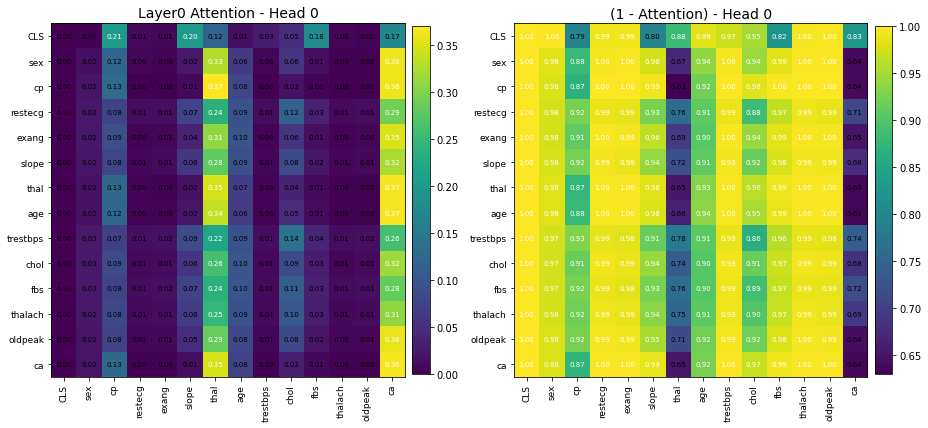

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0030 | std=0.2043
            sex  | mean=0.0363 | std=2.2336
             cp  | mean=0.2807 | std=5.9917
        restecg  | mean=0.3145 | std=6.4825
          exang  | mean=0.0740 | std=2.6730
          slope  | mean=0.2332 | std=5.7132
           thal  | mean=0.2306 | std=5.3918
            age  | mean=-0.1288 | std=6.3892
       trestbps  | mean=0.0095 | std=0.2759
           chol  | mean=-0.2017 | std=4.6270
            fbs  | mean=-0.0926 | std=2.2001
        thalach  | mean=0.6204 | std=14.2182
        oldpeak  | mean=-0.2213 | std=5.3015
             ca  | mean=-0.0438 | std=2.0763

=== Global embedding statistics ===
global mean: 0.0796
global std : 5.6961


In [27]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



In [31]:
emb.shape

(14, 768)

Start Training (UMAP Trajectory Enabled - Increased Target Variance)...
   [Movement] Avg Step Size (vs last snapshot): 0.002542
   [Displacement] Avg Distance from Start:    0.002542
   [Gradient] Total Grad Norm:    0.059241
--------------------------------------------------
Epoch    0 | FGW Loss: 0.866936
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      891.66
   2. Structure Cost (GW) Max:   0.03 (Internal Term)
   3. Actual Ratio (GW / M):    0.00
   4. source embedding norm : 1.254272222518921 source embedding mean : -5.793723903479986e-05 source embedding grad : 2.5922563509084284e-06
Epoch    0 | Total Loss: 0.866936
  [Input Scales] M Max: 891.7 (Raw) vs C1 Max: 1.0000 (Raw)
  [Contribution] Feat: 0.0 (100.0%) vs Struc: 0.0000 (0.0%)


   [Movement] Avg Step Size (vs last snapshot): 0.226663
   [Displacement] Avg Distance from Start:    0.229206
   [Gradient] Total Grad Norm:    0.045933
--------------------------------------------------
Epoch  100 | FGW Loss: 0.731177
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:      1,050.94
   2. Structure Cost (GW) Max:   56.87 (Internal Term)
   3. Actual Ratio (GW / M):    0.00
   4. source embedding norm : 2.951589345932007 source embedding mean : -0.0001698207634035498 source embedding grad : 1.9538033484423067e-06
Epoch  100 | Total Loss: 0.731177
  [Input Scales] M Max: 1050.9 (Raw) vs C1 Max: 1.0000 (Raw)
  [Contribution] Feat: 0.0 (100.0%) vs Struc: 0.0000 (0.0%)
   [Movement] Avg Step Size (vs last snapshot): 0.187713
   [Displacement] Avg Distance from Start:    0.416917
   [Gradient] Total Grad Norm:    0.037980
--------------------------------------------------
Epoch  200 | FGW Loss: 0.644034
   [RAW COST SCALE COMPARISON]
   1. Feature Cost (M) Max:    

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


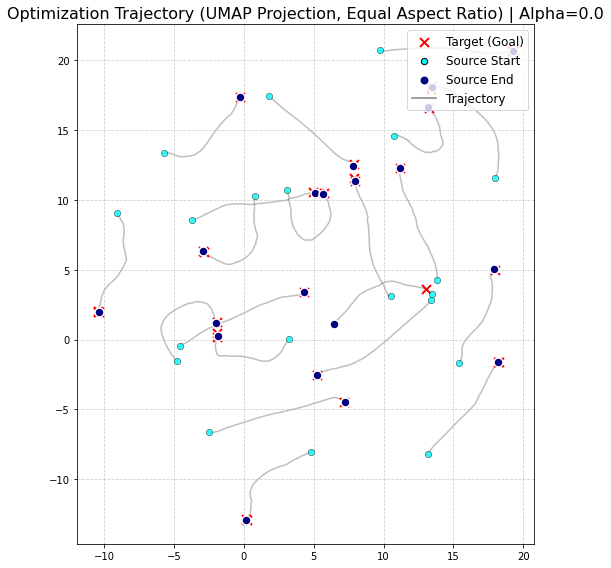

Visualizing Cost Evolution (Raw Scales)...


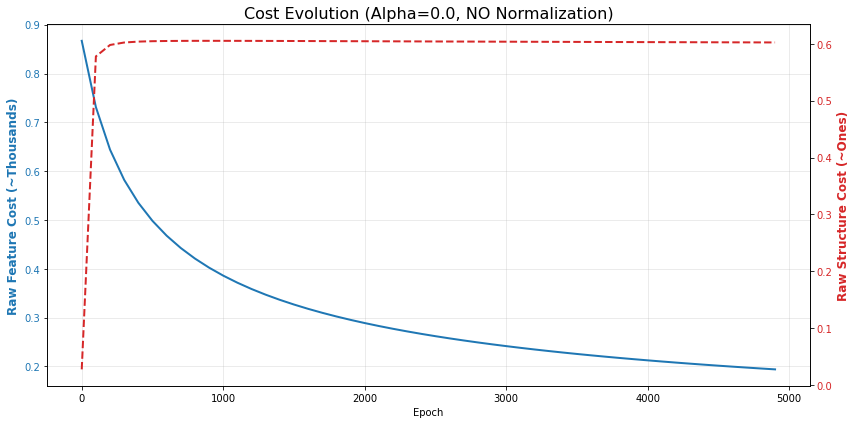

Visualizing Transport Plans...


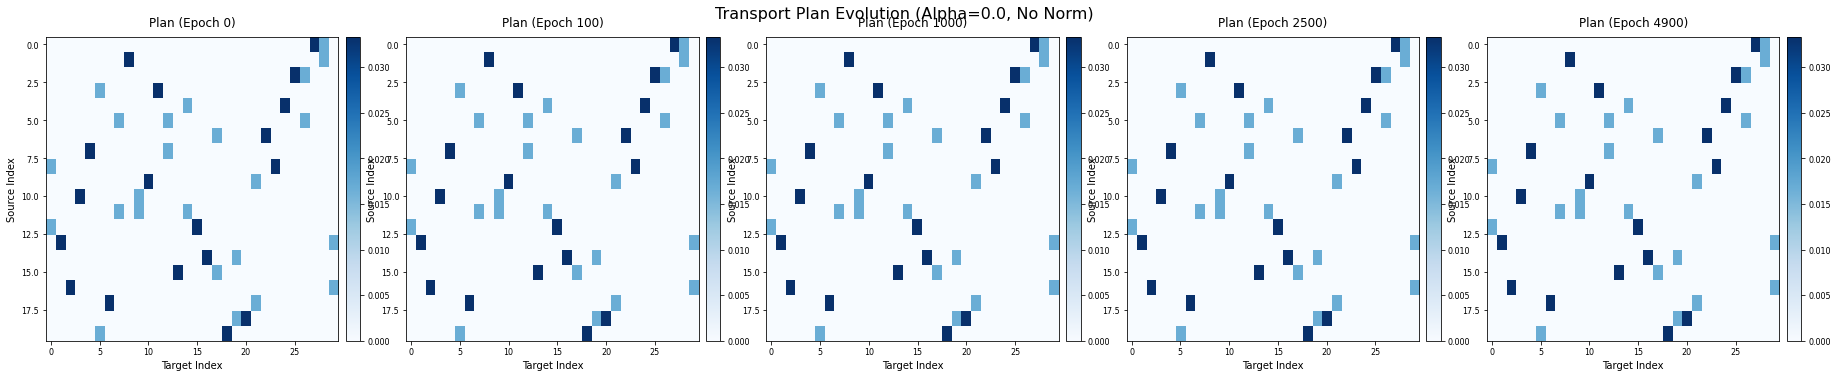

In [97]:
import torch
import torch.optim as optim
import ot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA for visualization.")
        UMAP_AVAILABLE = False

# 실제 GW Loss 항의 최대값 계산
# # C1의 최대값과 C2의 최소값(혹은 그 반대)의 차이의 제곱이 최대 비용이 됩니다.
# gw_cost_max = (C1.max() - C2.min()) ** 2

# print(f"1. Feature Cost (M) Max:      {M.max():,.2f}")
# print(f"2. Structure Cost (GW) Max:   {gw_cost_max:,.2f} (Internal Term)")
# print(f"3. Actual Ratio (GW / M):     {gw_cost_max / M.max():.2f}")
# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = 30
dim = 768
EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# [Target Data]: Target 클러스터 내부 분산을 10배 키워서 (0.1 -> 1.0) UMAP이 퍼뜨리도록 유도
target_emb = torch.randn(n_target, dim) * 1.0 # 분산 증대 (이전 0.1)
# target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# Source Data (Learnable): Target과 겹쳐서 시작
source_emb = torch.randn(n_source, dim, requires_grad=True)

# 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
with torch.no_grad():
    source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# Distribution weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=target_emb)

# -----------------------------------------------------------------------------
# 2. Training Loop (Robust Normalization)
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

print("Start Training (UMAP Trajectory Enabled - Increased Target Variance)...")
loss_history = []
feat_cost_history = []
struc_cost_history = []

# Plan 시각화용
snapshot_epochs = [0, 100, 1000, 2500, 4900]
plan_snapshots = {}
alpha = 0.0

# 초기 상태
source_history = [source_emb.detach().cpu().numpy().copy()]

# [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
n_epochs = 5000
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # --- Matrix Computation ---
    M_raw = ot.dist(source_emb, target_emb)
    C1_raw = ot.dist(source_emb, source_emb)
    C2_raw = ot.dist(target_emb, target_emb)

    # Robust Max Normalization (NaN 방지)
    M = M_raw / (M_raw.max() + EPSILON) 
    C1 = C1_raw / (C1_raw.max() + EPSILON)
    C2 = C2_raw / (C2_raw.max() + EPSILON)

    # --- FGW Loss ---
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
    M, C1, C2, p, q,
    loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping training.")
        break

    # --- Update ---
    fgw_loss.backward()
    optimizer.step()

    loss_history.append(fgw_loss.item())

    # [로그 출력]
    if epoch % 100 == 0:
        with torch.no_grad():
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun = 'square_loss', alpha = alpha)
            if epoch in snapshot_epochs:
                plan_snapshots[epoch] = T.detach().cpu().numpy() 
            current_feat_cost = torch.sum(M * T).item() 
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item() 
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            weight_feat = (1 - alpha) * current_feat_cost 
            weighted_struc = alpha * current_struc_cost 
            total_weight = weighted_feat + weighted_struc + EPSILON
            raw_m_max = M_raw.max().item()
            c1_max_val = C1.max().item() 
        gw_max_cost = (C1_raw.max().item() - C1_raw.min().item())**2
        actual_ratio = gw_cost_max / (raw_m_max + EPSILON)
        if len(source_history) > 0: 
            prev_emb = source_history[-1]
            curr_emb = source_emb.detach().cpu().numpy() 
            diff = np.linalg.norm(curr_emb - prev_emb, axis = 1).mean() 
            print(f"   [Movement] Avg Step Size (vs last snapshot): {diff:.6f}")
            init_emb = source_history[0]
            displacement = np.linalg.norm(curr_emb - init_emb, axis = 1).mean() 
            print(f"   [Displacement] Avg Distance from Start:    {displacement:.6f}")
        if source_emb.grad is not None:
            grad_norm = source_emb.grad.norm().item() 
            print(f"   [Gradient] Total Grad Norm:    {grad_norm:.6f}")

        print("-" * 50)
        print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
        print("   [RAW COST SCALE COMPARISON]")
        print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
        print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
        print(f"   3. Actual Ratio (GW / M):    {actual_ratio:,.2f}")
        print(f"   4. source embedding norm : {source_emb.norm().item()} source embedding mean : {source_emb.mean().item()} source embedding grad : {source_emb.grad.mean().item()}")
        # 매 스텝 저장
        print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
        print(f"  [Input Scales] M Max: {raw_m_max:.1f} (Raw) vs C1 Max: {c1_max_val:.4f} (Raw)")
        print(f"  [Contribution] Feat: {weighted_feat:.1f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
        source_history.append(source_emb.detach().cpu().numpy().copy())

# 최종 상태
source_history.append(source_emb.detach().cpu().numpy().copy())
print("-" * 50)
print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# -----------------------------------------------------------------------------
print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
projection_method = "UMAP"

# [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
all_data = np.vstack(source_history + [target_emb.numpy()])

if UMAP_AVAILABLE:
    # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
else:
    # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

# 데이터 분리
target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx

source_2d_history = np.array(source_2d_history) 

# 그래프 그리기
plt.figure(figsize=(12, 8))
ax = plt.gca() # 현재 축을 가져옵니다.

# 1. Target (Goal) - 빨간색 X
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# 2. Source Trajectories
for i in range(n_source):
    traj = source_2d_history[:, i, :]

    # 이동 경로 선 (진한 회색)
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)

    # 시작점 (하늘색)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)

    # 끝점 (진한 파랑)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# [핵심 수정] UMAP/PCA 시각화에서는 축 비율을 1:1로 강제합니다.
ax.set_aspect('equal', adjustable='box') 

# Legend (가짜 핸들 생성)
plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Cost Evolution (Dual Axis required due to scale)
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution (Raw Scales)...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Raw Feature Cost (~Thousands)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Raw Structure Cost (~Ones)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha}, NO Normalization)", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. Visualization: Transport Plan Snapshots (Improved)
# -----------------------------------------------------------------------------
if plan_snapshots:
    print("Visualizing Transport Plans...")
    
    def plot_single_plan(ax, matrix, title):
        im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Target Index", fontsize=10)
        ax.set_ylabel("Source Index", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cb = plt.colorbar(im, cax=cax)
        cb.ax.tick_params(labelsize=8)
        return ax

    n_snaps = len(plan_snapshots)
    fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
    if n_snaps == 1: axes = [axes]
    
    sorted_epochs = sorted(plan_snapshots.keys())
    for i, epoch in enumerate(sorted_epochs):
        plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
    plt.suptitle(f"Transport Plan Evolution (Alpha={alpha}, No Norm)", fontsize=16, y=1.02)
    plt.show()

In [87]:
# import torch
# import torch.optim as optim
# import ot
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE 
# # UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# # UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
# try:
#     import umap.umap_ as umap
#     UMAP_AVAILABLE = True
# except ImportError:
#     try:
#         import umap
#         UMAP_AVAILABLE = True
#     except ImportError:
#         print("UMAP not found. Falling back to PCA for visualization.")
#         UMAP_AVAILABLE = False


# # -----------------------------------------------------------------------------
# # 1. Setup Data
# # -----------------------------------------------------------------------------
# torch.manual_seed(42)
# np.random.seed(42)

# n_source = 20
# n_target = 30
# dim = 768
# EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# # [Target Data]: Target 클러스터를 중앙에 모아 UMAP이 더 잘 분리하도록 유도
# target_emb = torch.randn(n_target, dim) * 1.0 
# # target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# # target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# # Source Data (Learnable): Target과 겹쳐서 시작
# source_emb = torch.randn(n_source, dim, requires_grad=True)

# # 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
# with torch.no_grad():
#     source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# # Distribution weights
# p = ot.unif(n_source, type_as=source_emb)
# q = ot.unif(n_target, type_as=target_emb)

# # -----------------------------------------------------------------------------
# # 2. Training Loop (Robust Normalization)
# # -----------------------------------------------------------------------------
# optimizer = optim.SGD([source_emb], lr=0.5) 

# print("Start Training (UMAP Trajectory Enabled)...")
# loss_history = []
# source_history = [] 
# alpha = 0.0 

# # 초기 상태
# source_history.append(source_emb.detach().cpu().numpy().copy())

# # [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
# n_epochs = 5000
# for epoch in range(n_epochs):
#     optimizer.zero_grad()
    
#     # --- Matrix Computation ---
#     M_raw = ot.dist(source_emb, target_emb)
#     C1_raw = ot.dist(source_emb, source_emb)
#     C2_raw = ot.dist(target_emb, target_emb)
    
#     # Robust Max Normalization (NaN 방지)
#     M = M_raw / (M_raw.max() + EPSILON) 
#     C1 = C1_raw / (C1_raw.max() + EPSILON)
#     C2 = C2_raw / (C2_raw.max() + EPSILON)
    
#     # --- FGW Loss ---
#     fgw_loss = ot.gromov.fused_gromov_wasserstein2(
#         M, C1, C2, p, q,
#         loss_fun='square_loss', alpha=alpha
#     )
    
#     if torch.isnan(fgw_loss):
#         print("Loss is NaN! Stopping training.")
#         break

#     # --- Update ---
#     fgw_loss.backward()
#     optimizer.step()
    
#     loss_history.append(fgw_loss.item())
    
#     # [로그 출력]
#     if epoch % 100 == 0:
#         raw_m_max = M_raw.max().item()
#         gw_max_cost = (C1_raw.max().item() - C2_raw.min().item())**2
#         actual_ratio = gw_max_cost / (raw_m_max + EPSILON)
        
#         print("-" * 50)
#         print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
#         print("   [RAW COST SCALE COMPARISON]")
#         print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
#         print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
#         print(f"   3. Actual Ratio (GW / M):     {actual_ratio:,.2f}")
#         # 매 스텝 저장
#         source_history.append(source_emb.detach().cpu().numpy().copy())

# # 최종 상태
# source_history.append(source_emb.detach().cpu().numpy().copy())
# print("-" * 50)
# print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# # -----------------------------------------------------------------------------
# # 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# # -----------------------------------------------------------------------------
# print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
# projection_method = "UMAP"

# # [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
# # 이렇게 해야 모든 궤적이 하나의 일관된 좌표계를 가집니다.
# all_data = np.vstack(source_history + [target_emb.numpy()])

# if UMAP_AVAILABLE:
#     # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
#     reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
#     data_2d = reducer.fit_transform(all_data)
# else:
#     # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
#     pca = PCA(n_components=2)
#     data_2d = pca.fit_transform(all_data)
#     projection_method = "PCA"

# # 데이터 분리
# target_2d = data_2d[-n_target:]
# source_2d_history = []
# start_idx = 0
# n_snapshots = len(source_history)
# for _ in range(n_snapshots):
#     end_idx = start_idx + n_source
#     source_2d_history.append(data_2d[start_idx:end_idx])
#     start_idx = end_idx

# source_2d_history = np.array(source_2d_history) 

# # 그래프 그리기
# plt.figure(figsize=(12, 8))
# ax = plt.gca() # 현재 축을 가져옵니다.

# # 1. Target (Goal) - 빨간색 X
# plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# # 2. Source Trajectories
# for i in range(n_source):
#     traj = source_2d_history[:, i, :]
    
#     # 이동 경로 선 (진한 회색)
#     plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)
    
#     # 시작점 (하늘색)
#     plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)
    
#     # 끝점 (진한 파랑)
#     plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# # [핵심 수정] UMAP 시각화에서는 축 비율을 1:1로 강제합니다.
# ax.set_aspect('equal', adjustable='box') 

# # Legend (가짜 핸들 생성)
# plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
# plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
# plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

# plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
# plt.legend(loc='upper right', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

In [39]:
node = emb[1:]
print(node.shape)

(13, 768)


In [44]:
attn_matrix = torch.tensor(atts[0], dtype=torch.float32)
C2_raw = 1.0 - attn_matrix 

attn_matrix.shape

torch.Size([1, 14, 14])

Start Training (Feature MaxNorm: ON, Structure MaxNorm: OFF, Alpha=0.8)...
Epoch    0 | Total Loss: 0.094366
  [Scales]       M Raw Max: 3192.8 -> Norm Max: 1.0
                 C1 Raw Max: 1.1192 (No Norm applied)
  [Contribution] Feat: 0.0444 (47.0%) vs Struc: 0.0500 (53.0%)
Epoch  100 | Total Loss: 0.082829
  [Scales]       M Raw Max: 3193.0 -> Norm Max: 1.0
                 C1 Raw Max: 0.9450 (No Norm applied)
  [Contribution] Feat: 0.0444 (53.6%) vs Struc: 0.0385 (46.4%)
Epoch  200 | Total Loss: 0.082038
  [Scales]       M Raw Max: 3193.3 -> Norm Max: 1.0
                 C1 Raw Max: 0.9503 (No Norm applied)
  [Contribution] Feat: 0.0443 (54.0%) vs Struc: 0.0377 (46.0%)
Epoch  300 | Total Loss: 0.079303
  [Scales]       M Raw Max: 3193.7 -> Norm Max: 1.0
                 C1 Raw Max: 0.9471 (No Norm applied)
  [Contribution] Feat: 0.0443 (55.9%) vs Struc: 0.0350 (44.1%)
Epoch  400 | Total Loss: 0.078997
  [Scales]       M Raw Max: 3194.0 -> Norm Max: 1.0
                 C1 Raw Max

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


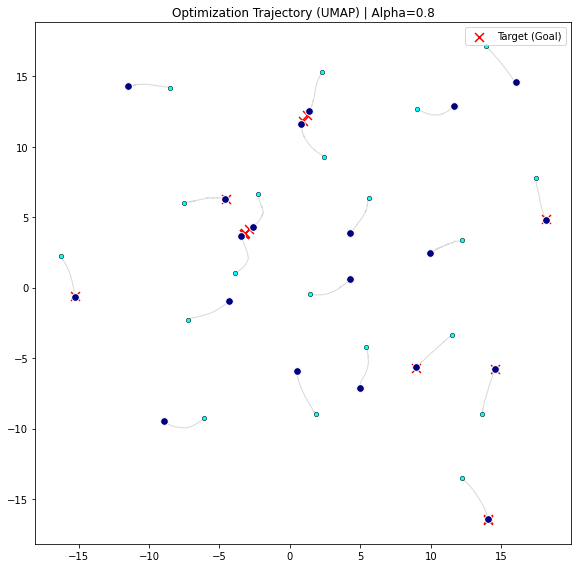

Visualizing Cost Evolution...


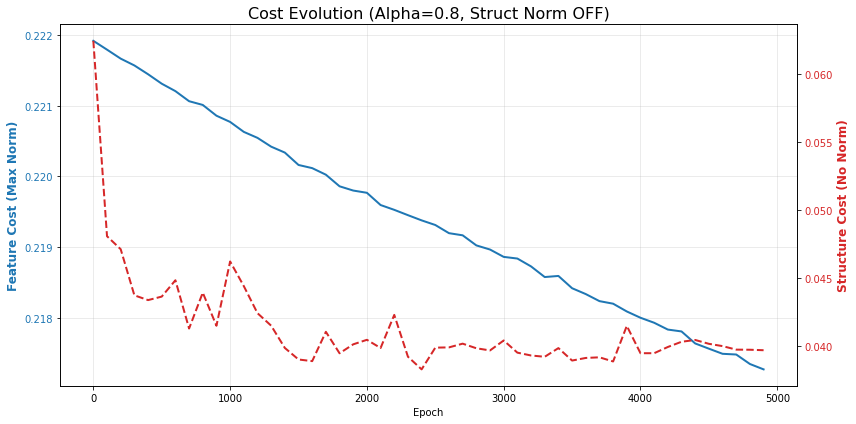

In [78]:
import torch
import torch.optim as optim
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# UMAP 확인
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA.")
        UMAP_AVAILABLE = False

# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = node.shape[0] # 13
dim = 768
EPSILON = 1e-9 

# [Target Data]
if isinstance(node, np.ndarray):
    target_emb = torch.from_numpy(node).float()
else:
    target_emb = node.detach().clone().float()

# [Target Standardization]
t_mean = target_emb.mean(dim=0)
t_std = target_emb.std(dim=0) + EPSILON
target_emb = (target_emb - t_mean) / t_std

# [Target Structure (C2)] Stretched 1-Affinity
attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# 1. Affinity -> Cost
C2_raw = 1.0 - attn_matrix 
C2_raw.fill_diagonal_(0.0) 

# (옵션) Setup 단계에서의 Min-Max Stretching은 데이터 전처리이므로 유지
# 이것은 "분포"를 0~1로 펴주는 것이지, 매 step마다 크기를 죽이는 Normalization과는 다름
# c2_min = C2_raw.min()
# c2_max = C2_raw.max()
# C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# [Source Data]
source_emb = torch.randn(n_source, dim, requires_grad=True)
with torch.no_grad():
    source_emb.data *= 0.01 

# Weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=source_emb)

# Device
device = source_emb.device
target_emb = target_emb.to(device)
C2_raw = C2_raw.to(device)

# -----------------------------------------------------------------------------
# 2. Training Loop
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

# Feature와 Structure의 스케일이 자연스럽게 0~1 근처로 맞춰졌으므로
# Alpha는 0.5 ~ 0.8 사이 추천
alpha = 0.8
n_epochs = 5000

print(f"Start Training (Feature MaxNorm: ON, Structure MaxNorm: OFF, Alpha={alpha})...")

loss_history = []
feat_cost_history = []
struc_cost_history = []
source_history = [source_emb.detach().cpu().numpy().copy()]

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # ----------------------------------------------------------------
    # 1. Feature Cost (M): Euclidean
    # ----------------------------------------------------------------
    # 값 범위: ~3000 (Standardized 768 dim)
    M_raw = ot.dist(source_emb, target_emb)
    
    # ----------------------------------------------------------------
    # 2. Structure Cost (C1): Cosine Distance
    # ----------------------------------------------------------------
    # 값 범위: 0.0 ~ 2.0
    source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
    cosine_sim = torch.mm(source_norm, source_norm.t())
    C1_raw = 1.0 - cosine_sim
    C1_raw = torch.clamp(C1_raw, min=0.0)
    C1_raw.fill_diagonal_(0.0)

    # ----------------------------------------------------------------
    # 3. Normalization (Feature ONLY)
    # ----------------------------------------------------------------
    # [요청 반영] Feature는 3000 -> 1.0으로 압축 (필수)
    m_max = M_raw.max().detach() + EPSILON
    M = M_raw / m_max
    
    # [요청 반영] Structure는 Normalization 제거 (Raw Scale 사용)
    # C1(0~2), C2(0~1) 범위 그대로 들어갑니다.
    C1 = C1_raw 
    C2 = C2_raw 

    # FGW Loss
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping.")
        break

    fgw_loss.backward()
    optimizer.step()
    loss_history.append(fgw_loss.item())

    # Logging & Stats
    if epoch % 100 == 0:
        with torch.no_grad():
            # Contribution 계산
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
            # Normalized Feature Cost
            current_feat_cost = torch.sum(M * T).item()
            
            # Un-Normalized Structure Cost
            # init_matrix는 원래 C1, C2를 그대로 씁니다.
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            
            weighted_feat = (1 - alpha) * current_feat_cost
            weighted_struc = alpha * current_struc_cost
            total_weight = weighted_feat + weighted_struc + EPSILON
            
            raw_m_max = M_raw.max().item()
            # 구조 비용의 Raw Max (Source 구조가 0~2 범위인지 확인)
            c1_max_val = C1_raw.max().item()

        print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
        print(f"  [Scales]       M Raw Max: {raw_m_max:.1f} -> Norm Max: 1.0")
        print(f"                 C1 Raw Max: {c1_max_val:.4f} (No Norm applied)")
        print(f"  [Contribution] Feat: {weighted_feat:.4f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
        source_history.append(source_emb.detach().cpu().numpy().copy())

source_history.append(source_emb.detach().cpu().numpy().copy())
print("Training Finished.")

# -----------------------------------------------------------------------------
# 3. Visualization
# -----------------------------------------------------------------------------
print("Visualizing Trajectories...")
target_numpy = target_emb.detach().cpu().numpy()
all_data = np.vstack(source_history + [target_numpy])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
    projection_method = "UMAP"
else:
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

target_2d = data_2d[-n_target:]
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)

for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx
source_2d_history = np.array(source_2d_history)

plt.figure(figsize=(10, 8))
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Dual Axis Plot
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Feature Cost (Max Norm)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Structure Cost (No Norm)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha}, Struct Norm OFF)", fontsize=16)
plt.tight_layout()
plt.show()

Start Training (Feature MaxNorm: ON, Structure MaxNorm: OFF, Alpha=0.8)...
Epoch    0 | Total Loss: 0.094302
  [Scales]       M Raw Max: 3192.8 -> Norm Max: 1.0
                 C1 Raw Max: 1.1192 (No Norm applied)
  [Contribution] Feat: 0.0444 (47.1%) vs Struc: 0.0499 (52.9%)
Epoch  100 | Total Loss: 0.080115
  [Scales]       M Raw Max: 3192.9 -> Norm Max: 1.0
                 C1 Raw Max: 0.9435 (No Norm applied)
  [Contribution] Feat: 0.0444 (55.4%) vs Struc: 0.0358 (44.6%)
Epoch  200 | Total Loss: 0.080728
  [Scales]       M Raw Max: 3193.2 -> Norm Max: 1.0
                 C1 Raw Max: 0.9463 (No Norm applied)
  [Contribution] Feat: 0.0443 (54.9%) vs Struc: 0.0364 (45.1%)
Epoch  300 | Total Loss: 0.080736
  [Scales]       M Raw Max: 3193.5 -> Norm Max: 1.0
                 C1 Raw Max: 0.9488 (No Norm applied)
  [Contribution] Feat: 0.0443 (54.9%) vs Struc: 0.0364 (45.1%)
Epoch  400 | Total Loss: 0.079958
  [Scales]       M Raw Max: 3193.9 -> Norm Max: 1.0
                 C1 Raw Max

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


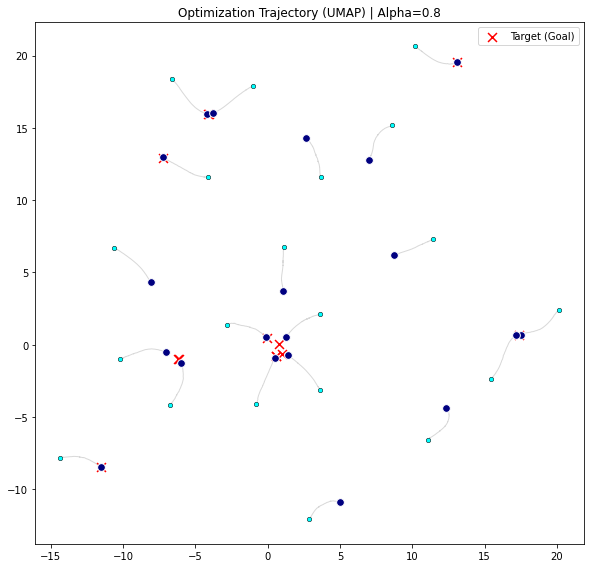

Visualizing Cost Evolution...


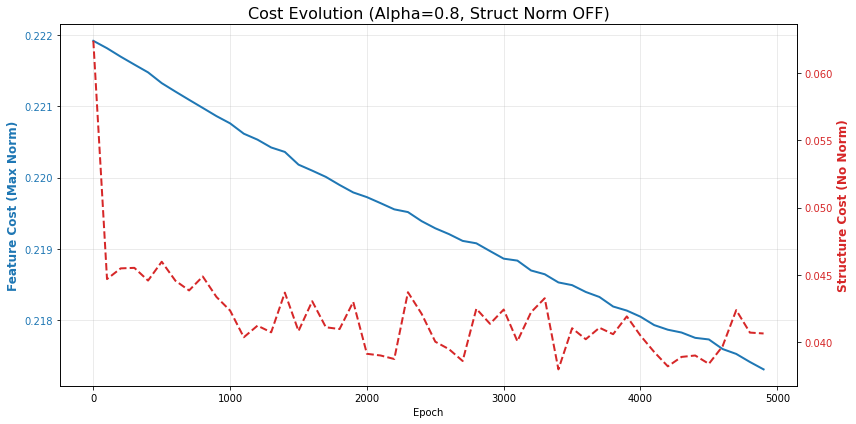

Visualizing Transport Plans...


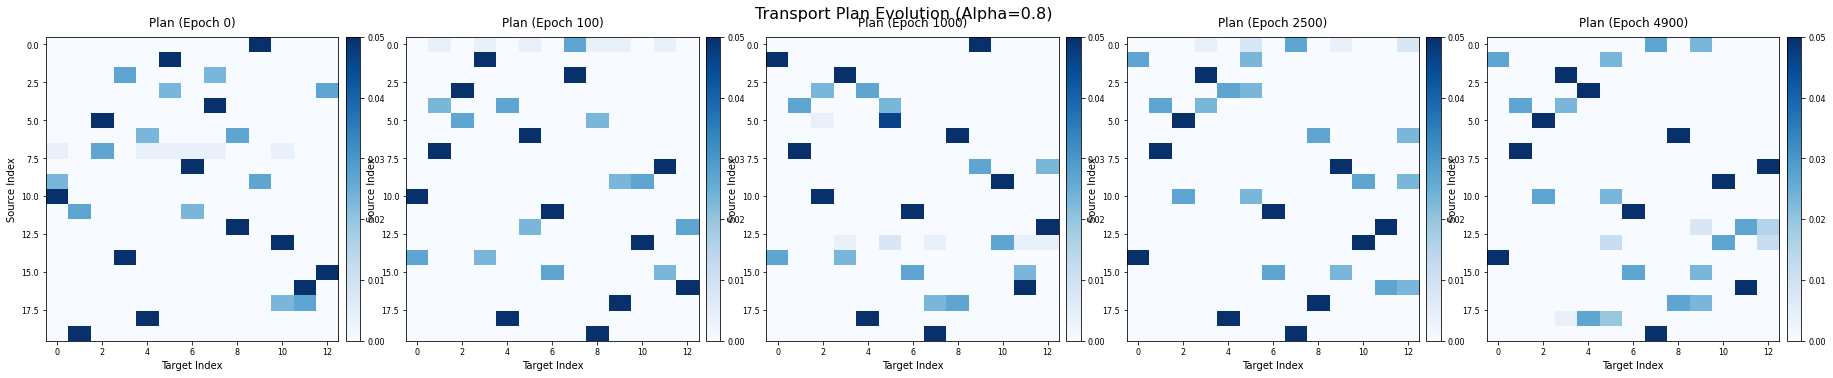

In [62]:
import torch
import torch.optim as optim
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.axes_grid1 import make_axes_locatable # 컬러바 정렬을 위해 추가

# UMAP 확인
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA.")
        UMAP_AVAILABLE = False

# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = node.shape[0] # 13
dim = 768
EPSILON = 1e-9 

# [Target Data]
if isinstance(node, np.ndarray):
    target_emb = torch.from_numpy(node).float()
else:
    target_emb = node.detach().clone().float()

# [Target Standardization]
t_mean = target_emb.mean(dim=0)
t_std = target_emb.std(dim=0) + EPSILON
target_emb = (target_emb - t_mean) / t_std

# [Target Structure (C2)] Stretched 1-Affinity
attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# 1. Affinity -> Cost
C2_raw = 1.0 - attn_matrix 
C2_raw.fill_diagonal_(0.0) 

# (옵션) Setup 단계에서의 Min-Max Stretching은 데이터 전처리이므로 유지
c2_min = C2_raw.min()
c2_max = C2_raw.max()
C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# [Source Data]
source_emb = torch.randn(n_source, dim, requires_grad=True)
with torch.no_grad():
    source_emb.data *= 0.01 

# Weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=source_emb)

# Device
device = source_emb.device
target_emb = target_emb.to(device)
C2_raw = C2_raw.to(device)

# -----------------------------------------------------------------------------
# 2. Training Loop
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

# Feature(Norm ON)와 Structure(Norm OFF)의 밸런스 조절
alpha = 0.8 
n_epochs = 5000

print(f"Start Training (Feature MaxNorm: ON, Structure MaxNorm: OFF, Alpha={alpha})...")

loss_history = []
feat_cost_history = []
struc_cost_history = []
source_history = [source_emb.detach().cpu().numpy().copy()]

# [Plan 시각화 설정]
snapshot_epochs = [0, 100, 1000, 2500, 4900] # Plan을 저장할 시점
plan_snapshots = {}

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # ----------------------------------------------------------------
    # 1. Feature Cost (M): Euclidean
    # ----------------------------------------------------------------
    M_raw = ot.dist(source_emb, target_emb)
    
    # ----------------------------------------------------------------
    # 2. Structure Cost (C1): Cosine Distance
    # ----------------------------------------------------------------
    source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
    cosine_sim = torch.mm(source_norm, source_norm.t())
    C1_raw = 1.0 - cosine_sim
    C1_raw = torch.clamp(C1_raw, min=0.0)
    C1_raw.fill_diagonal_(0.0)

    # ----------------------------------------------------------------
    # 3. Normalization (Feature ONLY)
    # ----------------------------------------------------------------
    # Feature는 3000 -> 1.0으로 압축
    m_max = M_raw.max().detach() + EPSILON
    M = M_raw / m_max
    
    # Structure는 Raw Scale 사용 (0~2 범위)
    C1 = C1_raw 
    C2 = C2_raw 

    # FGW Loss
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping.")
        break

    fgw_loss.backward()
    optimizer.step()
    loss_history.append(fgw_loss.item())

    # Logging & Stats
    if epoch % 100 == 0:
        with torch.no_grad():
            # Plan T 계산 (시각화 및 Contribution 용)
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
            # 스냅샷 저장
            if epoch in snapshot_epochs:
                plan_snapshots[epoch] = T.detach().cpu().numpy()

            # Normalized Feature Cost
            current_feat_cost = torch.sum(M * T).item()
            
            # Un-Normalized Structure Cost
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            
            weighted_feat = (1 - alpha) * current_feat_cost
            weighted_struc = alpha * current_struc_cost
            total_weight = weighted_feat + weighted_struc + EPSILON
            
            raw_m_max = M_raw.max().item()
            c1_max_val = C1_raw.max().item()

        print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
        print(f"  [Scales]       M Raw Max: {raw_m_max:.1f} -> Norm Max: 1.0")
        print(f"                 C1 Raw Max: {c1_max_val:.4f} (No Norm applied)")
        print(f"  [Contribution] Feat: {weighted_feat:.4f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
        source_history.append(source_emb.detach().cpu().numpy().copy())

source_history.append(source_emb.detach().cpu().numpy().copy())
print("Training Finished.")

# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories
# -----------------------------------------------------------------------------
print("Visualizing Trajectories...")
target_numpy = target_emb.detach().cpu().numpy()
all_data = np.vstack(source_history + [target_numpy])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
    projection_method = "UMAP"
else:
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

target_2d = data_2d[-n_target:]
source_2d_history = np.array(source_2d_history)
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx
source_2d_history = np.array(source_2d_history)

plt.figure(figsize=(10, 8))
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Dual Axis Plot
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Feature Cost (Max Norm)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Structure Cost (No Norm)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha}, Struct Norm OFF)", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. Visualization: Transport Plan Snapshots (개선된 버전)
# -----------------------------------------------------------------------------
if plan_snapshots:
    print("Visualizing Transport Plans...")
    
    def plot_single_plan(ax, matrix, title):
        im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto') # aspect='auto' 추가
        ax.set_title(title, fontsize=12, pad=10) # 폰트 크기 조절
        ax.set_xlabel("Target Index", fontsize=10) # 구체적인 라벨
        ax.set_ylabel("Source Index", fontsize=10) # 구체적인 라벨
        ax.tick_params(axis='both', which='major', labelsize=8)

        # 컬러바를 그림에 깔끔하게 정렬
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1) # 컬러바 크기/패딩 조절
        cb = plt.colorbar(im, cax=cax)
        cb.ax.tick_params(labelsize=8)
        return ax

    n_snaps = len(plan_snapshots)
    fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
    # axes가 리스트가 아닌 단일 객체일 경우를 대비 (스냅샷이 하나일 때)
    if n_snaps == 1: 
        axes = [axes]
    
    sorted_epochs = sorted(plan_snapshots.keys())
    for i, epoch in enumerate(sorted_epochs):
        plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
    plt.suptitle(f"Transport Plan Evolution (Alpha={alpha})", fontsize=16, y=1.02) # y값 조정
    plt.show()

Start Training (ALL Normalization: OFF, Alpha=0.8)...
Epoch    0 | Total Loss: 141.729233
  [Input Scales] M Max: 3192.8 (Raw) vs C1 Max: 1.1192 (Raw)
  [Contribution] Feat: 141.7 (100.0%) vs Struc: 0.0504 (0.0%)
Epoch  100 | Total Loss: 38.808838
  [Input Scales] M Max: 4496.5 (Raw) vs C1 Max: 1.5724 (Raw)
  [Contribution] Feat: 38.7 (99.7%) vs Struc: 0.1139 (0.3%)
Epoch  200 | Total Loss: 24.990541
  [Input Scales] M Max: 5225.3 (Raw) vs C1 Max: 1.5750 (Raw)
  [Contribution] Feat: 24.9 (99.5%) vs Struc: 0.1152 (0.5%)
Epoch  300 | Total Loss: 23.138977
  [Input Scales] M Max: 5525.6 (Raw) vs C1 Max: 1.5759 (Raw)
  [Contribution] Feat: 23.0 (99.5%) vs Struc: 0.1156 (0.5%)
Epoch  400 | Total Loss: 22.890921
  [Input Scales] M Max: 5640.0 (Raw) vs C1 Max: 1.5762 (Raw)
  [Contribution] Feat: 22.8 (99.5%) vs Struc: 0.1158 (0.5%)
Epoch  500 | Total Loss: 22.857637
  [Input Scales] M Max: 5682.5 (Raw) vs C1 Max: 1.5764 (Raw)
  [Contribution] Feat: 22.7 (99.5%) vs Struc: 0.1159 (0.5%)
Epoch  

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


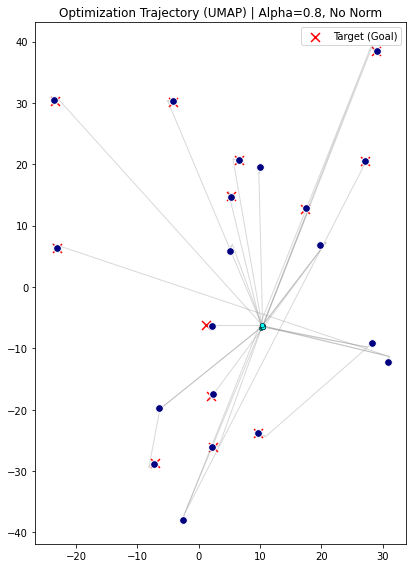

Visualizing Cost Evolution (Raw Scales)...


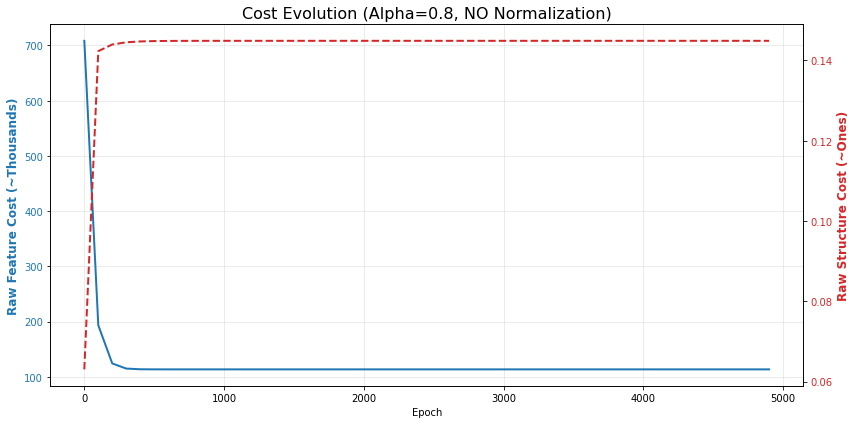

Visualizing Transport Plans...


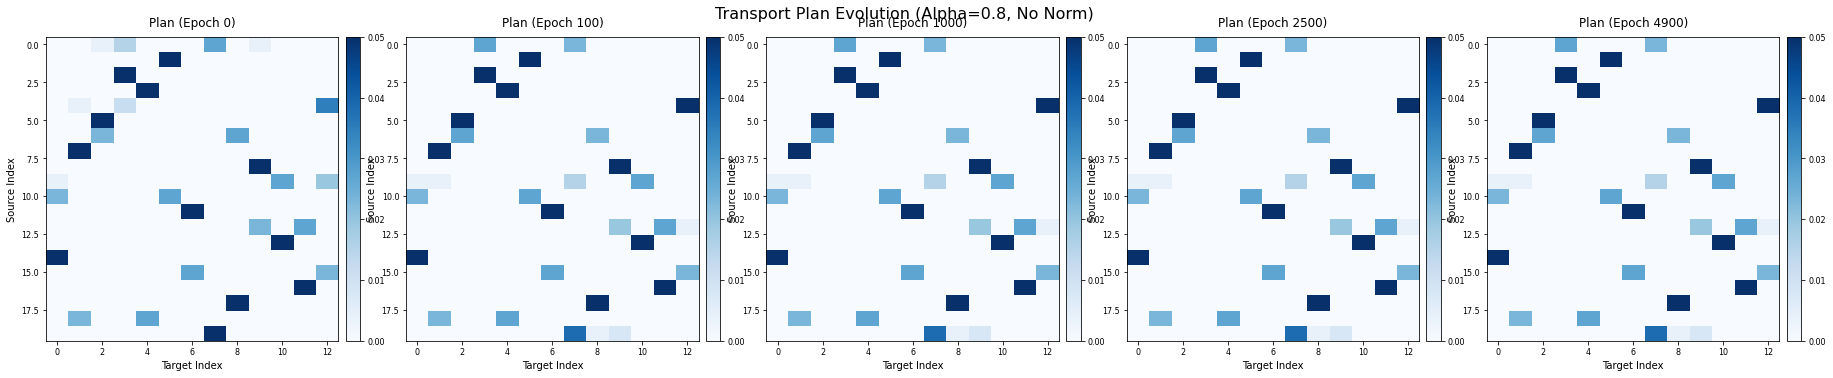

In [63]:
import torch
import torch.optim as optim
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.axes_grid1 import make_axes_locatable

# UMAP 확인
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA.")
        UMAP_AVAILABLE = False

# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = node.shape[0] # 13
dim = 768
EPSILON = 1e-9 

# [Target Data]
if isinstance(node, np.ndarray):
    target_emb = torch.from_numpy(node).float()
else:
    target_emb = node.detach().clone().float()

# [Target Standardization] (데이터 자체의 특이성 보존을 위해 유지)
t_mean = target_emb.mean(dim=0)
t_std = target_emb.std(dim=0) + EPSILON
target_emb = (target_emb - t_mean) / t_std

# [Target Structure (C2)] Stretched 1-Affinity
attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# 1. Affinity -> Cost
C2_raw = 1.0 - attn_matrix 
C2_raw.fill_diagonal_(0.0) 

# (옵션) Setup 단계의 Min-Max는 데이터 전처리이므로 유지
c2_min = C2_raw.min()
c2_max = C2_raw.max()
C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# [Source Data]
source_emb = torch.randn(n_source, dim, requires_grad=True)
with torch.no_grad():
    source_emb.data *= 0.01 

# Weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=source_emb)

# Device
device = source_emb.device
target_emb = target_emb.to(device)
C2_raw = C2_raw.to(device)

# -----------------------------------------------------------------------------
# 2. Training Loop
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

# Alpha 설정
alpha = 0.8 
n_epochs = 5000

print(f"Start Training (ALL Normalization: OFF, Alpha={alpha})...")
print("Warning: Expecting massive scale imbalance between Feature and Structure.")

loss_history = []
feat_cost_history = []
struc_cost_history = []
source_history = [source_emb.detach().cpu().numpy().copy()]

# Plan 시각화용
snapshot_epochs = [0, 100, 1000, 2500, 4900]
plan_snapshots = {}

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # ----------------------------------------------------------------
    # 1. Feature Cost (M): Euclidean
    # ----------------------------------------------------------------
    # 값 범위: ~3200 (Standardized 768 dim)
    M_raw = ot.dist(source_emb, target_emb)
    
    # ----------------------------------------------------------------
    # 2. Structure Cost (C1): Cosine Distance
    # ----------------------------------------------------------------
    # 값 범위: 0.0 ~ 2.0
    source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
    cosine_sim = torch.mm(source_norm, source_norm.t())
    C1_raw = 1.0 - cosine_sim
    C1_raw = torch.clamp(C1_raw, min=0.0)
    C1_raw.fill_diagonal_(0.0)

    # ----------------------------------------------------------------
    # 3. NO Normalization (Raw Scale Experiment)
    # ----------------------------------------------------------------
    # [핵심] Normalization을 아예 하지 않습니다.
    # M은 3000, C는 1.0인 상태 그대로 들어갑니다.
    M = M_raw 
    C1 = C1_raw 
    C2 = C2_raw 

    # FGW Loss
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping.")
        break

    fgw_loss.backward()
    optimizer.step()
    loss_history.append(fgw_loss.item())

    # Logging & Stats
    if epoch % 100 == 0:
        with torch.no_grad():
            # Plan T 계산
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
            # 스냅샷
            if epoch in snapshot_epochs:
                plan_snapshots[epoch] = T.detach().cpu().numpy()

            # Raw Feature Cost
            current_feat_cost = torch.sum(M * T).item()
            
            # Raw Structure Cost
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            
            # 가중치가 적용된 '실제 영향력' 비교
            # Normalization이 없으므로 M 값이 그대로 곱해져서 매우 클 것임
            weighted_feat = (1 - alpha) * current_feat_cost
            weighted_struc = alpha * current_struc_cost
            total_weight = weighted_feat + weighted_struc + EPSILON
            
            raw_m_max = M.max().item()
            c1_max_val = C1.max().item()

        print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
        print(f"  [Input Scales] M Max: {raw_m_max:.1f} (Raw) vs C1 Max: {c1_max_val:.4f} (Raw)")
        print(f"  [Contribution] Feat: {weighted_feat:.1f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
        source_history.append(source_emb.detach().cpu().numpy().copy())

source_history.append(source_emb.detach().cpu().numpy().copy())
print("Training Finished.")

# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories
# -----------------------------------------------------------------------------
print("Visualizing Trajectories...")
target_numpy = target_emb.detach().cpu().numpy()
all_data = np.vstack(source_history + [target_numpy])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
    projection_method = "UMAP"
else:
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

target_2d = data_2d[-n_target:]
source_2d_history = np.array(source_2d_history)
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx
source_2d_history = np.array(source_2d_history)

plt.figure(figsize=(10, 8))
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}, No Norm")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Cost Evolution (Dual Axis required due to scale)
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution (Raw Scales)...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Raw Feature Cost (~Thousands)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Raw Structure Cost (~Ones)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha}, NO Normalization)", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. Visualization: Transport Plan Snapshots (Improved)
# -----------------------------------------------------------------------------
if plan_snapshots:
    print("Visualizing Transport Plans...")
    
    def plot_single_plan(ax, matrix, title):
        im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Target Index", fontsize=10)
        ax.set_ylabel("Source Index", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cb = plt.colorbar(im, cax=cax)
        cb.ax.tick_params(labelsize=8)
        return ax

    n_snaps = len(plan_snapshots)
    fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
    if n_snaps == 1: axes = [axes]
    
    sorted_epochs = sorted(plan_snapshots.keys())
    for i, epoch in enumerate(sorted_epochs):
        plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
    plt.suptitle(f"Transport Plan Evolution (Alpha={alpha}, No Norm)", fontsize=16, y=1.02)
    plt.show()

Start Training (ALL Normalization: OFF, Alpha=0.9999)...
Epoch    0 | Total Loss: 2.745509
  [Input Scales] M Max: 155573.0 (Raw) vs C1 Max: 1.1192 (Raw)
  [Contribution] Feat: 2.7 (97.7%) vs Struc: 0.0620 (2.3%)
Epoch  100 | Total Loss: 2.726754
  [Input Scales] M Max: 155625.8 (Raw) vs C1 Max: 0.9701 (Raw)
  [Contribution] Feat: 2.7 (98.3%) vs Struc: 0.0453 (1.7%)
Epoch  200 | Total Loss: 2.725603
  [Input Scales] M Max: 155640.3 (Raw) vs C1 Max: 0.9785 (Raw)
  [Contribution] Feat: 2.7 (98.3%) vs Struc: 0.0453 (1.7%)
Epoch  300 | Total Loss: 2.722920
  [Input Scales] M Max: 155641.9 (Raw) vs C1 Max: 0.9892 (Raw)
  [Contribution] Feat: 2.7 (98.4%) vs Struc: 0.0435 (1.6%)
Epoch  400 | Total Loss: 2.723667
  [Input Scales] M Max: 155642.7 (Raw) vs C1 Max: 0.9980 (Raw)
  [Contribution] Feat: 2.7 (98.3%) vs Struc: 0.0451 (1.7%)
Epoch  500 | Total Loss: 2.719877
  [Input Scales] M Max: 155642.6 (Raw) vs C1 Max: 1.0018 (Raw)
  [Contribution] Feat: 2.7 (98.5%) vs Struc: 0.0421 (1.5%)
Epoch  

/home/eungyeop/anaconda3/envs/featllm/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


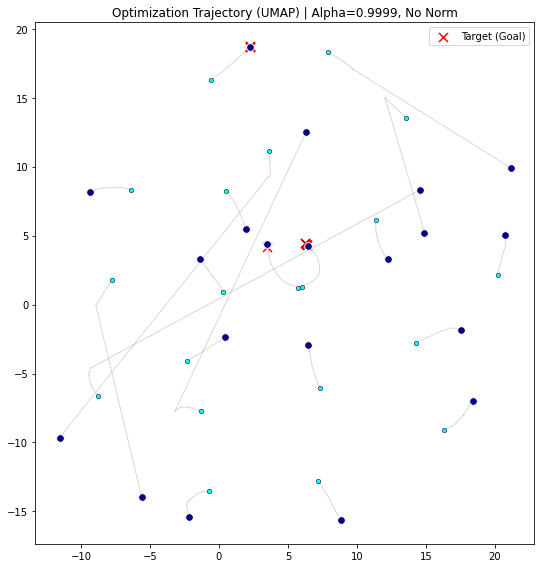

Visualizing Cost Evolution (Raw Scales)...


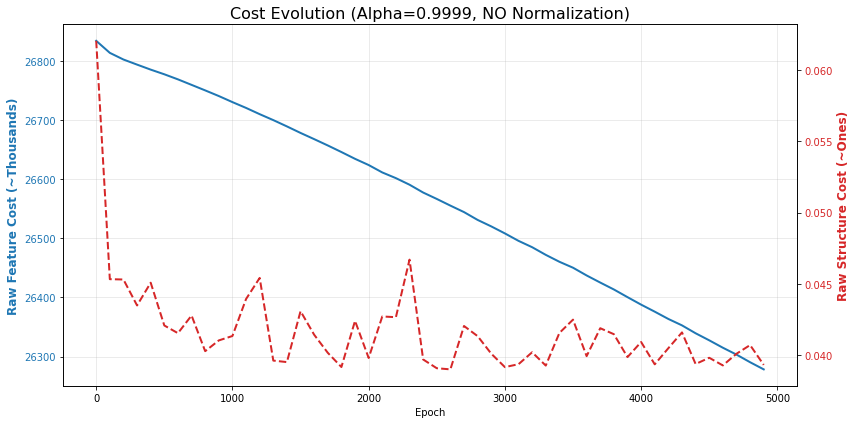

Visualizing Transport Plans...


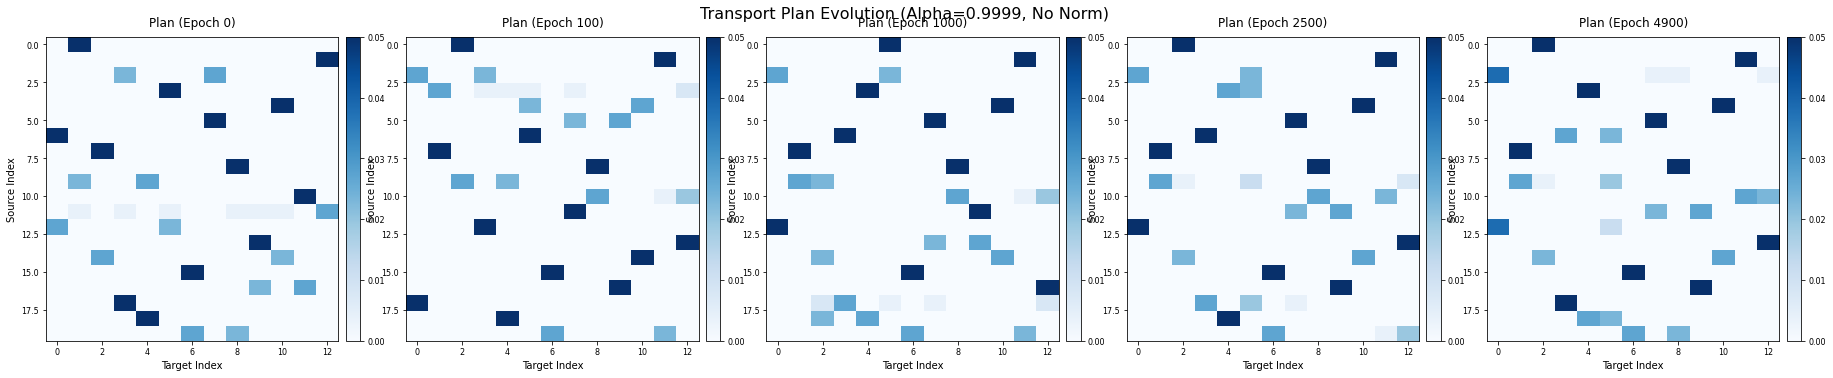

In [71]:
import torch
import torch.optim as optim
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.axes_grid1 import make_axes_locatable

# UMAP 확인
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    try:
        import umap
        UMAP_AVAILABLE = True
    except ImportError:
        print("UMAP not found. Falling back to PCA.")
        UMAP_AVAILABLE = False

# -----------------------------------------------------------------------------
# 1. Setup Data
# -----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

n_source = 20
n_target = node.shape[0] # 13
dim = 768
EPSILON = 1e-9 

# [Target Data]
if isinstance(node, np.ndarray):
    target_emb = torch.from_numpy(node).float()
else:
    target_emb = node.detach().clone().float()

# [Target Standardization] (데이터 자체의 특이성 보존을 위해 유지)
# t_mean = target_emb.mean(dim=0)
# t_std = target_emb.std(dim=0) + EPSILON
# target_emb = (target_emb - t_mean) / t_std

# [Target Structure (C2)] Stretched 1-Affinity
attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# 1. Affinity -> Cost
C2_raw = 1.0 - attn_matrix 
C2_raw.fill_diagonal_(0.0) 

# (옵션) Setup 단계의 Min-Max는 데이터 전처리이므로 유지
c2_min = C2_raw.min()
c2_max = C2_raw.max()
C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# [Source Data]
source_emb = torch.randn(n_source, dim, requires_grad=True)
with torch.no_grad():
    source_emb.data *= 0.01 

# Weights
p = ot.unif(n_source, type_as=source_emb)
q = ot.unif(n_target, type_as=source_emb)

# Device
device = source_emb.device
target_emb = target_emb.to(device)
C2_raw = C2_raw.to(device)

# -----------------------------------------------------------------------------
# 2. Training Loop
# -----------------------------------------------------------------------------
optimizer = optim.SGD([source_emb], lr=0.5) 

# Alpha 설정
alpha = 0.9999
n_epochs = 5000

print(f"Start Training (ALL Normalization: OFF, Alpha={alpha})...")
print("Warning: Expecting massive scale imbalance between Feature and Structure.")

loss_history = []
feat_cost_history = []
struc_cost_history = []
source_history = [source_emb.detach().cpu().numpy().copy()]

# Plan 시각화용
snapshot_epochs = [0, 100, 1000, 2500, 4900]
plan_snapshots = {}

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # ----------------------------------------------------------------
    # 1. Feature Cost (M): Euclidean
    # ----------------------------------------------------------------
    # 값 범위: ~3200 (Standardized 768 dim)
    M_raw = ot.dist(source_emb, target_emb)
    
    # ----------------------------------------------------------------
    # 2. Structure Cost (C1): Cosine Distance
    # ----------------------------------------------------------------
    # 값 범위: 0.0 ~ 2.0
    source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
    cosine_sim = torch.mm(source_norm, source_norm.t())
    C1_raw = 1.0 - cosine_sim
    C1_raw = torch.clamp(C1_raw, min=0.0)
    C1_raw.fill_diagonal_(0.0)

    # ----------------------------------------------------------------
    # 3. NO Normalization (Raw Scale Experiment)
    # ----------------------------------------------------------------
    # [핵심] Normalization을 아예 하지 않습니다.
    # M은 3000, C는 1.0인 상태 그대로 들어갑니다.
    M = M_raw 
    C1 = C1_raw 
    C2 = C2_raw 

    # FGW Loss
    fgw_loss = ot.gromov.fused_gromov_wasserstein2(
        M, C1, C2, p, q,
        loss_fun='square_loss', alpha=alpha
    )

    if torch.isnan(fgw_loss):
        print("Loss is NaN! Stopping.")
        break

    fgw_loss.backward()
    optimizer.step()
    loss_history.append(fgw_loss.item())

    # Logging & Stats
    if epoch % 100 == 0:
        with torch.no_grad():
            # Plan T 계산
            T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
            # 스냅샷
            if epoch in snapshot_epochs:
                plan_snapshots[epoch] = T.detach().cpu().numpy()

            # Raw Feature Cost
            current_feat_cost = torch.sum(M * T).item()
            
            # Raw Structure Cost
            constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
            current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
            feat_cost_history.append(current_feat_cost)
            struc_cost_history.append(current_struc_cost)
            
            # 가중치가 적용된 '실제 영향력' 비교
            # Normalization이 없으므로 M 값이 그대로 곱해져서 매우 클 것임
            weighted_feat = (1 - alpha) * current_feat_cost
            weighted_struc = alpha * current_struc_cost
            total_weight = weighted_feat + weighted_struc + EPSILON
            
            raw_m_max = M.max().item()
            c1_max_val = C1.max().item()

        print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
        print(f"  [Input Scales] M Max: {raw_m_max:.1f} (Raw) vs C1 Max: {c1_max_val:.4f} (Raw)")
        print(f"  [Contribution] Feat: {weighted_feat:.1f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
        source_history.append(source_emb.detach().cpu().numpy().copy())

source_history.append(source_emb.detach().cpu().numpy().copy())
print("Training Finished.")

# -----------------------------------------------------------------------------
# 3. Visualization: Trajectories
# -----------------------------------------------------------------------------
print("Visualizing Trajectories...")
target_numpy = target_emb.detach().cpu().numpy()
all_data = np.vstack(source_history + [target_numpy])

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
    data_2d = reducer.fit_transform(all_data)
    projection_method = "UMAP"
else:
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(all_data)
    projection_method = "PCA"

target_2d = data_2d[-n_target:]
source_2d_history = np.array(source_2d_history)
source_2d_history = []
start_idx = 0
n_snapshots = len(source_history)
for _ in range(n_snapshots):
    end_idx = start_idx + n_source
    source_2d_history.append(data_2d[start_idx:end_idx])
    start_idx = end_idx
source_2d_history = np.array(source_2d_history)

plt.figure(figsize=(10, 8))
plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
for i in range(n_source):
    traj = source_2d_history[:, i, :]
    plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
    plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
    plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}, No Norm")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. Visualization: Cost Evolution (Dual Axis required due to scale)
# -----------------------------------------------------------------------------
print("Visualizing Cost Evolution (Raw Scales)...")
epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Raw Feature Cost (~Thousands)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx() 
color2 = 'tab:red'
ax2.set_ylabel('Raw Structure Cost (~Ones)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Cost Evolution (Alpha={alpha}, NO Normalization)", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. Visualization: Transport Plan Snapshots (Improved)
# -----------------------------------------------------------------------------
if plan_snapshots:
    print("Visualizing Transport Plans...")
    
    def plot_single_plan(ax, matrix, title):
        im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
        ax.set_title(title, fontsize=12, pad=10)
        ax.set_xlabel("Target Index", fontsize=10)
        ax.set_ylabel("Source Index", fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cb = plt.colorbar(im, cax=cax)
        cb.ax.tick_params(labelsize=8)
        return ax

    n_snaps = len(plan_snapshots)
    fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
    if n_snaps == 1: axes = [axes]
    
    sorted_epochs = sorted(plan_snapshots.keys())
    for i, epoch in enumerate(sorted_epochs):
        plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
    plt.suptitle(f"Transport Plan Evolution (Alpha={alpha}, No Norm)", fontsize=16, y=1.02)
    plt.show()